# KNN (clasificación) — reingreso a 30 días en pacientes diabéticos

Este notebook aplica **K vecinos más cercanos (KNN)** al dataset limpio `diabetic_clean.csv` (un encuentro por paciente, sin faltantes), construido y analizado en `EDA/EDA_diabetes.ipynb` y un EDA del dataset limpio.

**Objetivo:** predecir `readmitted_30` = 1 si el paciente **reingresa en menos de 30 días** y 0 en otro caso (`>30` o `NO`).

**Prioridad: no dejar pasar reingresos.** Un *falso negativo* (el paciente sí reingresó y el modelo no lo marcó) es el error grave: ese paciente se fue a casa sin seguimiento. Un *falso positivo* (marcar a alguien que no reingresó) cuesta poco: una llamada o un control extra. Por eso el umbral se elige para **maximizar el recall** de `<30` (detectar al menos el 80 % de los reingresos), aceptando más falsas alarmas.

**¿Por qué binario y no 3 clases?** El reingreso temprano (`<30`) es el evento clínicamente relevante (es el que penalizan los hospitales y el que interesa prevenir); separar `>30` de `NO` agrega una distinción difusa que el EDA mostró casi sin señal. Al final hay una sección corta con las 3 clases solo como comparación.

**Lo que ya sabemos del EDA (y que condiciona todo el modelado):**
- el objetivo está **muy desbalanceado**: solo **9.0 %** es `<30`;
- la **señal es débil**: la mejor numérica sola (`time_in_hospital`) tiene AUC 0.56 y la mejor categórica (`discharge_disposition_id`) Cramér's V 0.14 → hay que esperar un AUC modesto (≈ 0.6);
- las visitas previas son 87–93 % ceros → usamos las versiones `_log`;
- hay columnas redundantes (`age`/`age_num`, raw/`_log`, `diabetesMed`) y `patient_nbr` **no** es una feature (contiene información de tiempo).

**Plan:**
1. Selección de features y agrupación de categorías
2. Split train/test y `Pipeline` de preprocesamiento
3. Línea base (`DummyClassifier`) y por qué *accuracy* engaña
4. Búsqueda de hiperparámetros con validación cruzada (AUC)
5. Elección del umbral de probabilidad (manejo del desbalance)
6. Evaluación final en test: intervalos de confianza, calibración, comparación con regresión logística y gradient boosting, y curva de decisión
7. ¿Ayudan las variables categóricas? ¿Y las que recomienda la literatura?
8. (Extra) 3 clases
9. Propuesta de uso: seguimiento en dos niveles (teleconsulta y cita presencial)
10. Conclusiones

In [1]:
import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_predict, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neighbors import KNeighborsClassifier
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score, recall_score, precision_score,
                             balanced_accuracy_score, accuracy_score, confusion_matrix, roc_curve,
                             precision_recall_curve)

C = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4', '#008300', '#4a3aa7', '#e34948']
MUTED = '#898781'
INK = '#52514e'
plt.rcParams.update({
    'figure.dpi': 110, 'figure.facecolor': '#fcfcfb', 'axes.facecolor': '#fcfcfb',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': MUTED, 'axes.labelcolor': '#52514e', 'xtick.color': '#52514e', 'ytick.color': '#52514e',
    'axes.grid': True, 'grid.color': '#e6e5e0', 'grid.linewidth': 0.6, 'axes.axisbelow': True,
    'axes.titleweight': 'bold', 'axes.titlesize': 11, 'font.size': 9, 'axes.prop_cycle': plt.cycler(color=C),
})
pd.set_option('display.width', 140)
T0 = time.time()
RS = 42

## 1. Datos y selección de features

In [2]:
# Busca la carpeta Data/ subiendo desde la carpeta actual (funciona desde la raíz del repo o desde EDA/ y Modelos/)
DATA = next(p / 'Data' for p in [Path.cwd(), *Path.cwd().parents] if (p / 'Data').is_dir())
df = pd.read_csv(DATA / 'diabetic_clean.csv')
print(df.shape)
print(df['readmitted_30'].value_counts(normalize=True).rename('proporción').round(3))

(69987, 39)
readmitted_30
0    0.91
1    0.09
Name: proporción, dtype: float64


### 1.1 ¿Qué features usamos y por qué?

KNN decide **solo por distancias**: cada columna que agregamos pesa en la distancia, sea útil o no. Con una señal tan débil, agregar columnas irrelevantes *diluye* a las pocas que sirven. Por eso usamos **pocas features** elegidas con el EDA:

| Tipo | Features | Motivo |
|---|---|---|
| Numéricas (8) | `number_inpatient_log`, `number_emergency_log`, `number_outpatient_log` | visitas previas; versión `_log` para limitar outliers |
| | `time_in_hospital`, `num_medications`, `num_lab_procedures`, `number_diagnoses` | intensidad / complejidad de la hospitalización |
| | `age_num` | edad (versión numérica, no ambas) |
| Categóricas (2) | `discharge_disposition_id` **agrupado** | la categórica más asociada al objetivo (V = 0.14) |
| | `diag_1` (capítulo ICD-9 del diagnóstico principal) | 10 categorías, ya agrupadas |

Quedan fuera: `patient_nbr` (ID con información temporal), duplicados (`age`, versiones sin log, `diabetesMed`), `medical_specialty` (48 % desconocido y muchas categorías) y medicamentos casi constantes.

`discharge_disposition_id` tiene 20 categorías, muchas con < 1 % de filas. En one-hot eso serían 20 columnas casi vacías, así que la **agrupamos** en 7 destinos con sentido clínico. En `diag_1`, la categoría `Desconocido` tiene solo 10 filas y se une a `Otros`.

In [3]:
def agrupar_alta(s):
    s_low = s.lower()
    if s == 'Desconocido':
        return 'Desconocido'
    if s == 'Discharged to home':
        return 'Casa'
    if 'home health' in s_low or 'home iv' in s_low:
        return 'Casa + servicio de salud'
    if 'snf' in s_low or 'icf' in s_low or 'nursing facility' in s_low or 'swing bed' in s_low:
        return 'SNF / enfermería'
    if 'rehab' in s_low:
        return 'Rehabilitación'
    if 'hospital' in s_low or 'inpatient care' in s_low or 'federal' in s_low:
        return 'Otro hospital / institución'
    return 'Otro (AMA, ambulatorio)'

df['alta_grupo'] = df['discharge_disposition_id'].map(agrupar_alta)
df['diag_1_grp'] = df['diag_1'].replace({'Desconocido': 'Otros'})

# Tabla de control: cómo quedó cada categoría original
control = (df.groupby(['alta_grupo', 'discharge_disposition_id']).size()
             .rename('n').reset_index().sort_values(['alta_grupo', 'n'], ascending=[True, False]))
control['discharge_disposition_id'] = control['discharge_disposition_id'].str.slice(0, 70)
control

,alta_grupo,discharge_disposition_id,n
0,Casa,Discharged to home,44320
2,Casa + servicio de salud,Discharged/transferred to home with home healt...,8291
1,Casa + servicio de salud,Discharged/transferred to home under care of H...,73
3,Desconocido,Desconocido,3252
6,"Otro (AMA, ambulatorio)",Left AMA,409
5,"Otro (AMA, ambulatorio)",Discharged/transferred/referred to this instit...,8
4,"Otro (AMA, ambulatorio)",Discharged/transferred/referred another instit...,3
7,"Otro (AMA, ambulatorio)",Still patient or expected to return for outpat...,2
11,Otro hospital / institución,Discharged/transferred to another short term h...,1541
12,Otro hospital / institución,Discharged/transferred to another type of inpa...,913


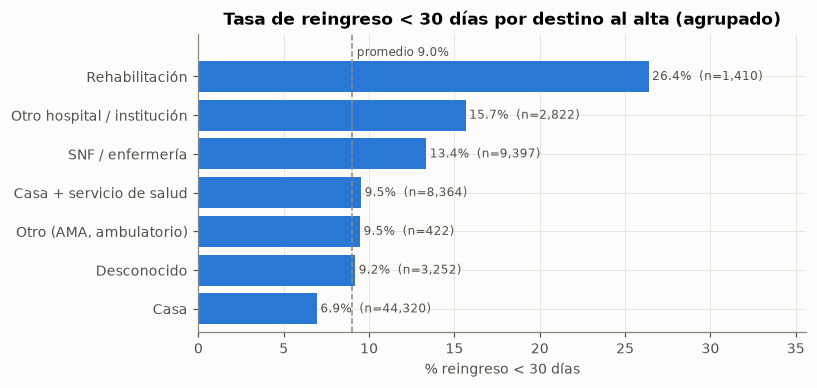

In [4]:
tasa = (df.groupby('alta_grupo')['readmitted_30'].agg(['mean', 'size'])
          .sort_values('mean'))
base = df['readmitted_30'].mean()

fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.barh(tasa.index, tasa['mean'] * 100, color=C[0])
ax.axvline(base * 100, color=MUTED, ls='--', lw=1)
ax.text(base * 100 + 0.3, len(tasa) - 0.55, f'promedio {base:.1%}', color=INK, fontsize=8, va='bottom')
for i, (m, n) in enumerate(zip(tasa['mean'], tasa['size'])):
    ax.text(m * 100 + 0.2, i, f'{m:.1%}  (n={n:,})', va='center', color=INK, fontsize=8)
ax.set_xlabel('% reingreso < 30 días')
ax.set_title('Tasa de reingreso < 30 días por destino al alta (agrupado)')
ax.set_xlim(0, tasa['mean'].max() * 100 * 1.35)
ax.set_ylim(-0.6, len(tasa) + 0.1)
plt.tight_layout(); plt.show()

La agrupación conserva la señal que vio el EDA: los pacientes enviados a **rehabilitación** reingresan en < 30 días un **26.4 %** de las veces (casi 3 veces el promedio de 9.0 %), los transferidos a **otro hospital** un 15.7 % y los enviados a **SNF / enfermería** un 13.4 %. Los enviados a **casa** (63 % de los pacientes) están por debajo del promedio (6.9 %). Con 7 grupos en vez de 20 categorías, todas las dummies tienen al menos ~400 pacientes.

In [5]:
NUM = ['number_inpatient_log', 'number_emergency_log', 'number_outpatient_log', 'time_in_hospital',
       'num_medications', 'num_lab_procedures', 'number_diagnoses', 'age_num']
CAT = ['alta_grupo', 'diag_1_grp']
TARGET = 'readmitted_30'

X = df[NUM + CAT]
y = df[TARGET]
print('Features:', len(NUM), 'numéricas +', len(CAT), 'categóricas')

Features: 8 numéricas + 2 categóricas


## 2. Split train/test y `Pipeline`

- **80 / 20 estratificado** (`stratify=y`): así train y test mantienen el 9 % de `<30`.
- Todo el preprocesamiento vive dentro de un `Pipeline` con `ColumnTransformer`. Así el `StandardScaler` y el `OneHotEncoder` se **ajustan solo con train** (y, dentro de la validación cruzada, solo con los folds de entrenamiento). Si escaláramos antes de separar, la media y desviación del test se “filtrarían” al modelo (*data leakage*).
- **Escalado:** KNN es sensible a la escala. Sin escalar, `num_lab_procedures` (0–130) dominaría la distancia frente a `number_emergency_log` (0–4). Las numéricas se estandarizan (media 0, desviación 1).
- **One-hot:** las dummies quedan en 0/1 (sin escalar). Dos pacientes con distinto destino al alta difieren en 2 dummies → aportan 2 a la distancia Manhattan (o √2 a la euclídea), comparable a una diferencia de 1–2 desviaciones estándar en una numérica.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RS)
print(f'train: {X_train.shape}  | % <30 = {y_train.mean():.2%}')
print(f'test:  {X_test.shape}  | % <30 = {y_test.mean():.2%}')

def hacer_preproceso(num, cat):
    trans = [('num', StandardScaler(), num)]
    if cat:
        trans.append(('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat))
    return ColumnTransformer(trans)

pre = hacer_preproceso(NUM, CAT)
n_cols = pre.fit(X_train).transform(X_train.head()).shape[1]
print(f'Columnas después del preprocesamiento: {n_cols} (vs ~145 con one-hot de todo)')

train: (55989, 10)  | % <30 = 8.98%
test:  (13998, 10)  | % <30 = 8.98%
Columnas después del preprocesamiento: 24 (vs ~145 con one-hot de todo)


## 3. Línea base: `DummyClassifier` y por qué *accuracy* engaña

El `DummyClassifier(strategy='most_frequent')` ignora las features y siempre predice la clase mayoritaria (0 = “no reingresa”). Cualquier modelo útil tiene que superarlo en las métricas que importan.

In [7]:
dummy = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
pred_d = dummy.predict(X_test)
proba_d = dummy.predict_proba(X_test)[:, 1]

print(f'Accuracy          : {accuracy_score(y_test, pred_d):.3f}')
print(f'Balanced accuracy : {balanced_accuracy_score(y_test, pred_d):.3f}')
print(f'Recall (<30)      : {recall_score(y_test, pred_d):.3f}')
print(f'F1 (<30)          : {f1_score(y_test, pred_d, zero_division=0):.3f}')
print(f'ROC-AUC           : {roc_auc_score(y_test, proba_d):.3f}')
print(f'Average precision : {average_precision_score(y_test, proba_d):.3f}  (= prevalencia de <30)')

Accuracy          : 0.910
Balanced accuracy : 0.500
Recall (<30)      : 0.000
F1 (<30)          : 0.000
ROC-AUC           : 0.500
Average precision : 0.090  (= prevalencia de <30)


El Dummy obtiene **~91 % de accuracy sin detectar ni un solo reingreso** (recall = 0). Con 9 % de positivos, “decir siempre que no” ya da 91 %. Por eso:
- **no usamos accuracy** para elegir ni comparar modelos;
- usamos **ROC-AUC** (qué tan bien *ordena* el modelo a los pacientes por riesgo; 0.5 = azar) y **average precision** (área bajo la curva precision-recall; la línea base es la prevalencia, 0.09);
- y, una vez fijado un umbral, **recall, precision, F1** de la clase `<30` y **balanced accuracy** (promedio del recall de cada clase; 0.5 = azar).

## 4. Búsqueda de hiperparámetros con validación cruzada

Hiperparámetros de KNN que exploramos:
- **`n_neighbors` (k):** k chico → frontera muy irregular (sobreajuste, probabilidades “a saltos”); k grande → más suave. Con una señal débil y 9 % de positivos, se esperan **k grandes**: con k = 5 la probabilidad estimada solo puede valer 0, 0.2, 0.4…, lo que ordena mal a los pacientes.
- **`weights`:** `uniform` (todos los vecinos votan igual) o `distance` (los más cercanos pesan más).
- **`metric`:** `euclidean` o `manhattan`. Manhattan suele funcionar mejor con variables discretas/dummies porque no eleva al cuadrado las diferencias.

Optimizamos **ROC-AUC** con `StratifiedKFold` de 5 folds y registramos también **average precision**.

⚠️ **Submuestra:** KNN calcula distancias contra todo el conjunto de entrenamiento, y la distancia Manhattan es lenta (~30 s por cada combinación con los 56 000 pacientes de train). Para que la grilla completa tarde pocos minutos, **la búsqueda se hace sobre una submuestra estratificada del 50 % de train** (~28 000 filas). Después, en 4.2, verificamos k con el train completo, porque el k óptimo tiende a crecer con el tamaño de la muestra.

In [8]:
X_sub, _, y_sub, _ = train_test_split(X_train, y_train, train_size=0.5, stratify=y_train, random_state=RS)
print(f'Submuestra para la búsqueda: {X_sub.shape[0]:,} filas | % <30 = {y_sub.mean():.2%}')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RS)
pipe = Pipeline([('pre', hacer_preproceso(NUM, CAT)), ('knn', KNeighborsClassifier())])

K_GRID = [5, 15, 31, 51, 75, 101, 151, 201, 301, 451]
param_grid = {
    'knn__n_neighbors': K_GRID,
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan'],
}
grid = GridSearchCV(pipe, param_grid, cv=cv, scoring={'auc': 'roc_auc', 'ap': 'average_precision'},
                    refit='auc', n_jobs=-1)
t = time.time()
grid.fit(X_sub, y_sub)
print(f'Búsqueda: {len(K_GRID) * 4} combinaciones x 5 folds en {time.time() - t:.0f} s')
print('Mejores hiperparámetros:', grid.best_params_)
print(f'AUC CV = {grid.best_score_:.4f}')

Submuestra para la búsqueda: 27,994 filas | % <30 = 8.98%


Búsqueda: 40 combinaciones x 5 folds en 51 s
Mejores hiperparámetros: {'knn__metric': 'manhattan', 'knn__n_neighbors': 451, 'knn__weights': 'uniform'}
AUC CV = 0.6310


In [9]:
res = pd.DataFrame(grid.cv_results_)
res = res.rename(columns={'param_knn__n_neighbors': 'k', 'param_knn__weights': 'weights', 'param_knn__metric': 'metric'})
tabla = (res[['k', 'weights', 'metric', 'mean_test_auc', 'std_test_auc', 'mean_test_ap']]
         .sort_values('mean_test_auc', ascending=False).reset_index(drop=True))
tabla.head(10).round(4)

,k,weights,metric,mean_test_auc,std_test_auc,mean_test_ap
0,451,uniform,manhattan,0.6310,0.0058,0.1483
1,451,distance,manhattan,0.6305,0.0058,0.1483
2,301,uniform,manhattan,0.6295,0.0066,0.1481
3,201,uniform,manhattan,0.6288,0.0063,0.1483
4,301,distance,manhattan,0.6286,0.0069,0.1480
5,201,distance,manhattan,0.6270,0.0067,0.1478
6,151,uniform,manhattan,0.6255,0.0079,0.1461
7,451,distance,euclidean,0.6232,0.0080,0.1441
8,151,distance,manhattan,0.6231,0.0072,0.1461
9,451,uniform,euclidean,0.6231,0.0078,0.1454


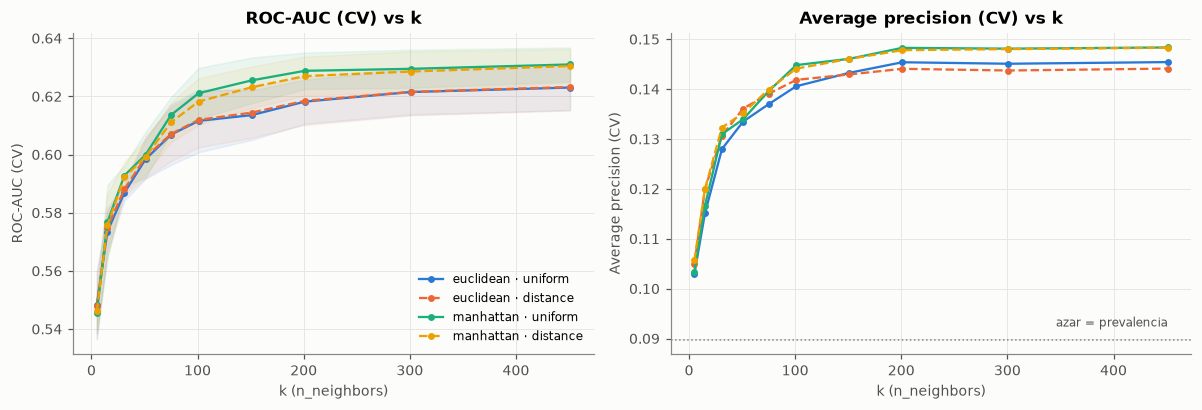

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
combos = [('euclidean', 'uniform'), ('euclidean', 'distance'), ('manhattan', 'uniform'), ('manhattan', 'distance')]
for col, (ax, met, lab) in enumerate(zip(axes, ['auc', 'ap'], ['ROC-AUC (CV)', 'Average precision (CV)'])):
    for i, (m, w) in enumerate(combos):
        r = res[(res['metric'] == m) & (res['weights'] == w)].sort_values('k')
        ks = r['k'].astype(int)
        ax.plot(ks, r[f'mean_test_{met}'], marker='o', ms=3.5, lw=1.5, color=C[i], label=f'{m} · {w}',
                ls='-' if w == 'uniform' else '--')
        if met == 'auc':
            ax.fill_between(ks, r['mean_test_auc'] - r['std_test_auc'], r['mean_test_auc'] + r['std_test_auc'],
                            color=C[i], alpha=0.08)
    ax.set_xlabel('k (n_neighbors)'); ax.set_ylabel(lab); ax.set_title(f'{lab} vs k')
axes[1].axhline(y_sub.mean(), color=MUTED, ls=':', lw=1)
axes[1].text(K_GRID[-1], y_sub.mean() + 0.002, 'azar = prevalencia', color=INK, fontsize=8, ha='right', va='bottom')
axes[0].legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()

**Qué muestra la búsqueda (submuestra del 50 % de train):**
- **k es, por lejos, el hiperparámetro más importante.** Con k = 5 el AUC es apenas **0.55**; sube rápido hasta k ≈ 100 y después se aplana (≈ 0.63 entre k = 200 y 451). Con 9 % de positivos y señal débil, el modelo necesita **cientos de vecinos** para estimar una probabilidad estable.
- **Manhattan > euclídea** en todos los k grandes (≈ +0.008 de AUC), coherente con tener variables discretas y dummies.
- **`weights`** casi no importa: `uniform` y `distance` quedan a menos de 0.002 de AUC. Con cientos de vecinos a distancias parecidas, ponderar por distancia cambia poco.
- Mejor combinación: **manhattan · uniform · k = 451**, AUC CV = **0.631**, AP CV = **0.148** (vs 0.09 del azar). El mejor k quedó en el borde de la grilla, pero la curva ya está plana; lo revisamos con el train completo.
- Las bandas (± 1 desviación estándar entre folds, ≈ 0.006) muestran que las diferencias entre k ≥ 200 están dentro del ruido.

### 4.2 Verificación de k con el train completo

La búsqueda usó 50 % de train, así que cada modelo de la CV “veía” ~22 000 pacientes. El modelo final tendrá ~56 000. Con más datos, un mismo k representa un **vecindario más pequeño** en el espacio de features, así que el k óptimo suele crecer. Fijamos `metric` y `weights` ganadores y comparamos algunos k (≈ 0.5×, 1×, 1.5×, 2× y 3× el mejor) con CV de 5 folds sobre **todo** train.

In [11]:
bp = grid.best_params_
k0 = bp['knn__n_neighbors']
K_FULL = sorted({max(5, int(round(k0 * f))) for f in [0.5, 1, 1.5, 2, 3]})
filas = []
t = time.time()
for k in K_FULL:
    p = Pipeline([('pre', hacer_preproceso(NUM, CAT)),
                  ('knn', KNeighborsClassifier(n_neighbors=k, weights=bp['knn__weights'], metric=bp['knn__metric']))])
    s = cross_validate(p, X_train, y_train, cv=cv, scoring={'auc': 'roc_auc', 'ap': 'average_precision'}, n_jobs=-1)
    filas.append({'k': k, 'AUC_CV': s['test_auc'].mean(), 'AUC_std': s['test_auc'].std(), 'AP_CV': s['test_ap'].mean()})
full_k = pd.DataFrame(filas)
print(f'Tiempo: {time.time() - t:.0f} s')
BEST_K = int(full_k.loc[full_k['AUC_CV'].idxmax(), 'k'])
print(f"Mejor k con train completo: {BEST_K}  (metric={bp['knn__metric']}, weights={bp['knn__weights']})")
full_k.round(4)

Tiempo: 69 s
Mejor k con train completo: 676  (metric=manhattan, weights=uniform)


,k,AUC_CV,AUC_std,AP_CV
0,226,0.6364,0.0023,0.1536
1,451,0.6390,0.0036,0.1551
2,676,0.6397,0.0038,0.1543
3,902,0.6387,0.0034,0.1530
4,1353,0.6359,0.0043,0.1498


Con el train completo el AUC es algo mayor (más datos → mejores estimaciones locales) y el máximo queda en **k = 676** (AUC CV = **0.640**), aunque la meseta entre k = 451 y 902 es prácticamente plana (0.639–0.640, con desviación ≈ 0.004). Con k = 1353 empieza a bajar: el vecindario se vuelve tan grande que la probabilidad se acerca al promedio global. Usamos **k = 676, manhattan, uniform** para el modelo final.

Nota: k = 676 es ~1.2 % del train. Suena enorme, pero para una clase del 9 % significa que la probabilidad se estima con ~60 positivos esperados por vecindario.

## 5. El umbral de decisión: priorizar el recall

`KNeighborsClassifier` **no tiene `class_weight`**. Su probabilidad es simplemente la fracción de vecinos que son `<30`. Como solo 9 % de los pacientes son positivos, es rarísimo que **más de la mitad** de los k vecinos lo sean → con el umbral por defecto de 0.5 el modelo casi nunca predice `<30`.

La solución es **mover el umbral**: predecir `<30` cuando la probabilidad supere un valor *t* más bajo. ¿Qué *t*? Depende de qué error nos importa más:

| Error | Qué significa | Costo |
|---|---|---|
| **Falso negativo (FN)** | reingresó y **no** lo marcamos | **alto**: se fue sin seguimiento |
| Falso positivo (FP) | lo marcamos y no reingresó | bajo: un control/llamada de más |

Como el FN es el error grave, el criterio es: **el umbral más alto que todavía detecta al menos el `RECALL_OBJETIVO` (80 %) de los reingresos**. Entre todos los umbrales que cumplen ese recall, el más alto es el que genera menos falsas alarmas.

Para elegirlo **sin mirar el test**:
1. obtenemos probabilidades *out-of-fold* en train con `cross_val_predict` (cada paciente recibe la predicción de un modelo que no lo vio);
2. buscamos en esas predicciones el umbral que cumple el recall objetivo.

Como referencia también calculamos el umbral que maximiza **F1** (equilibra precision y recall) y el que maximiza **F2** (da 4 veces más peso al recall que a la precision). `RECALL_OBJETIVO` se puede cambiar en la celda siguiente.

> **Ojo:** el 80 % es una elección nuestra, no sale de los datos. En la sección 6.4 (curva de decisión) se ve qué implica en términos de costo: aceptar como máximo ~14 falsas alarmas por cada reingreso detectado (en test, la razón observada fue 8.3).

In [12]:
knn_final = Pipeline([('pre', hacer_preproceso(NUM, CAT)),
                      ('knn', KNeighborsClassifier(n_neighbors=BEST_K, weights=bp['knn__weights'],
                                                   metric=bp['knn__metric']))])
t = time.time()
oof = cross_val_predict(knn_final, X_train, y_train, cv=cv, method='predict_proba', n_jobs=-1)[:, 1]
print(f'Probabilidades out-of-fold en {time.time() - t:.0f} s')
print(f'% de pacientes con probabilidad >= 0.5: {(oof >= 0.5).mean():.2%}\n')

prec, rec, thr = precision_recall_curve(y_train, oof)
prec, rec = prec[:-1], rec[:-1]                     # alinear con thr (thr ascendente, recall descendente)
marcados = np.array([(oof >= u).mean() for u in thr])   # % de pacientes que el modelo marcaría como <30

def f_beta(beta):
    return (1 + beta**2) * prec * rec / np.clip(beta**2 * prec + rec, 1e-12, None)

def umbral_para_recall(r_obj):
    # umbral MÁS ALTO que todavía cumple recall >= r_obj
    return float(thr[np.where(rec >= r_obj)[0].max()])

RECALL_OBJETIVO = 0.80
UMBRAL = umbral_para_recall(RECALL_OBJETIVO)
UMBRAL_F1 = float(thr[np.argmax(f_beta(1))])
UMBRAL_F2 = float(thr[np.argmax(f_beta(2))])

def fila(nombre, u):
    i = np.searchsorted(thr, u)
    return {'criterio': nombre, 'umbral': u, 'recall': rec[i], 'precision': prec[i],
            '% pacientes marcados': marcados[i] * 100,
            'marcados por reingreso detectado': marcados[i] / (rec[i] * y_train.mean())}

tabla_umbral = pd.DataFrame(
    [fila('máx. F1', UMBRAL_F1), fila('máx. F2', UMBRAL_F2)] +
    [fila(f'recall ≥ {r:.0%}', umbral_para_recall(r)) for r in [0.6, 0.7, 0.8, 0.9]]
).set_index('criterio')
print(f'Umbral elegido (recall ≥ {RECALL_OBJETIVO:.0%} en OOF de train): {UMBRAL:.3f}')
tabla_umbral.round(3)

Probabilidades out-of-fold en 13 s
% de pacientes con probabilidad >= 0.5: 0.00%

Umbral elegido (recall ≥ 80% en OOF de train): 0.065


,umbral,recall,precision,% pacientes marcados,marcados por reingreso detectado
criterio,,,,,
máx. F1,0.098,0.478,0.145,29.552,6.883
máx. F2,0.070,0.759,0.114,59.933,8.791
recall ≥ 60%,0.084,0.601,0.130,41.512,7.686
recall ≥ 70%,0.074,0.708,0.119,53.650,8.438
recall ≥ 80%,0.065,0.809,0.109,66.365,9.136
recall ≥ 90%,0.055,0.904,0.101,80.412,9.910


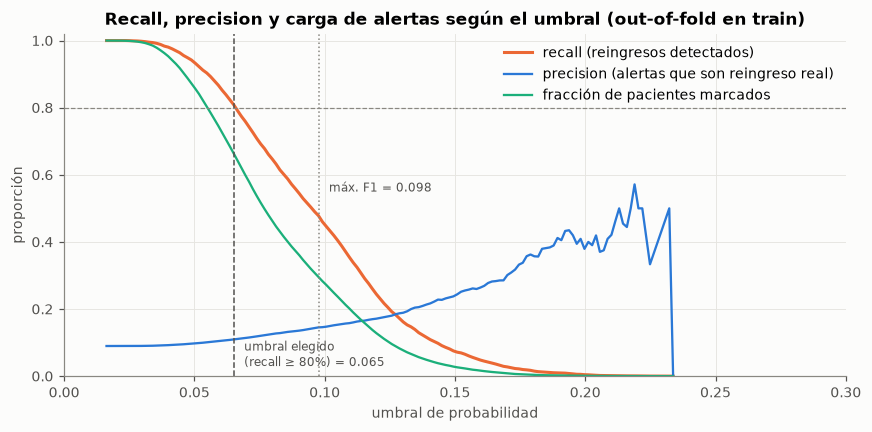

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thr, rec, color=C[1], lw=2, label='recall (reingresos detectados)')
ax.plot(thr, prec, color=C[0], lw=1.5, label='precision (alertas que son reingreso real)')
ax.plot(thr, marcados, color=C[2], lw=1.5, label='fracción de pacientes marcados')
ax.axvline(UMBRAL, color=INK, ls='--', lw=1)
ax.axvline(UMBRAL_F1, color=MUTED, ls=':', lw=1)
ax.axhline(RECALL_OBJETIVO, color=MUTED, ls='--', lw=0.8)
ax.text(UMBRAL + 0.004, 0.03, f'umbral elegido\n(recall ≥ {RECALL_OBJETIVO:.0%}) = {UMBRAL:.3f}', color=INK, fontsize=8)
ax.text(UMBRAL_F1 + 0.004, 0.55, f'máx. F1 = {UMBRAL_F1:.3f}', color=INK, fontsize=8)
ax.set_xlim(0, 0.3); ax.set_ylim(0, 1.02)
ax.set_xlabel('umbral de probabilidad'); ax.set_ylabel('proporción')
ax.set_title('Recall, precision y carga de alertas según el umbral (out-of-fold en train)')
ax.legend(frameon=False, loc='upper right')
plt.tight_layout(); plt.show()

## 6. Evaluación final en test

Ajustamos el pipeline final con **todo train** y evaluamos **una sola vez** en test. Comparamos:
- **Dummy** (siempre “no reingresa”) y **KNN con umbral 0.5**: no detectan a nadie;
- **Marcar a todos**: recall 100 %, pero no sirve para priorizar;
- **Marcar al azar** la misma cantidad de pacientes que el KNN elegido: es la comparación justa, porque muestra cuánto aporta el modelo frente a elegir pacientes a ciegas con la misma carga de trabajo;
- **KNN con umbral de máx. F1** (el criterio anterior) y **KNN con umbral de recall ≥ 80 %** (el elegido).

ROC-AUC y average precision no dependen del umbral, así que son iguales para todas las versiones de KNN.

In [14]:
knn_final.fit(X_train, y_train)
proba = knn_final.predict_proba(X_test)[:, 1]

def metricas(nombre, y_true, pred, score=None):
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {'modelo': nombre,
            'Recall (<30)': recall_score(y_true, pred, zero_division=0),
            'Reingresos NO detectados (FN)': fn,
            'Reingresos detectados (TP)': tp,
            'Falsas alarmas (FP)': fp,
            '% pacientes marcados': pred.mean() * 100,
            'Precision (<30)': precision_score(y_true, pred, zero_division=0),
            'F1 (<30)': f1_score(y_true, pred, zero_division=0),
            'Balanced acc.': balanced_accuracy_score(y_true, pred),
            'ROC-AUC': roc_auc_score(y_true, score) if score is not None else np.nan}

pred_05 = (proba >= 0.5).astype(int)
pred_f1 = (proba >= UMBRAL_F1).astype(int)
pred_t = (proba >= UMBRAL).astype(int)
pred_todos = np.ones(len(y_test), dtype=int)
pred_azar = (np.random.default_rng(RS).random(len(y_test)) < pred_t.mean()).astype(int)   # misma carga que el KNN elegido

tabla_test = pd.DataFrame([
    metricas('Dummy (nadie reingresa)', y_test, pred_d, proba_d),
    metricas('KNN · umbral 0.5', y_test, pred_05, proba),
    metricas('Marcar a todos', y_test, pred_todos),
    metricas(f'Marcar al azar ({pred_t.mean():.0%})', y_test, pred_azar),
    metricas(f'KNN · máx. F1 ({UMBRAL_F1:.3f})', y_test, pred_f1, proba),
    metricas(f'KNN · recall ≥ {RECALL_OBJETIVO:.0%} ({UMBRAL:.3f})', y_test, pred_t, proba),
]).set_index('modelo')
tabla_test.round(3)

,Recall (<30),Reingresos NO detectados (FN),Reingresos detectados (TP),Falsas alarmas (FP),% pacientes marcados,Precision (<30),F1 (<30),Balanced acc.,ROC-AUC
modelo,,,,,,,,,
Dummy (nadie reingresa),0.000,1257,0,0,0.000,0.000,0.000,0.500,0.500
KNN · umbral 0.5,0.000,1257,0,0,0.000,0.000,0.000,0.500,0.639
Marcar a todos,1.000,0,1257,12741,100.000,0.090,0.165,0.500,NaN
Marcar al azar (66%),0.682,400,857,8496,66.817,0.092,0.162,0.507,NaN
KNN · máx. F1 (0.098),0.484,649,608,3622,30.219,0.144,0.222,0.600,0.639
KNN · recall ≥ 80% (0.065),0.791,263,994,8266,66.152,0.107,0.189,0.571,0.639


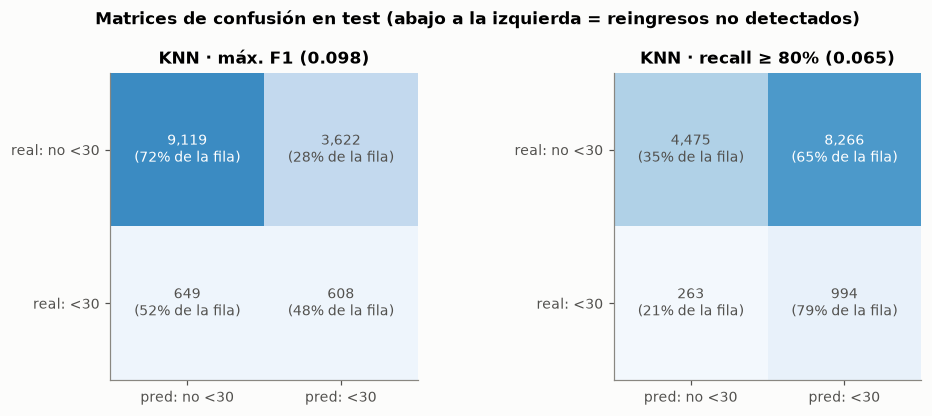

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.8))
for ax, pred, tit in zip(axes, [pred_f1, pred_t],
                         [f'KNN · máx. F1 ({UMBRAL_F1:.3f})', f'KNN · recall ≥ {RECALL_OBJETIVO:.0%} ({UMBRAL:.3f})']):
    cm = confusion_matrix(y_test, pred)
    ax.imshow(cm, cmap='Blues', vmin=0, vmax=cm.sum())
    ax.grid(False)
    for i in range(2):
        for j in range(2):
            pct = cm[i, j] / cm[i].sum()
            ax.text(j, i, f'{cm[i, j]:,}\n({pct:.0%} de la fila)', ha='center', va='center',
                    color='white' if cm[i, j] > cm.sum() * 0.5 else INK, fontsize=9)
    ax.set_xticks([0, 1], ['pred: no <30', 'pred: <30']); ax.set_yticks([0, 1], ['real: no <30', 'real: <30'])
    ax.set_title(tit)
plt.suptitle('Matrices de confusión en test (abajo a la izquierda = reingresos no detectados)', fontweight='bold', fontsize=11)
plt.tight_layout(); plt.show()

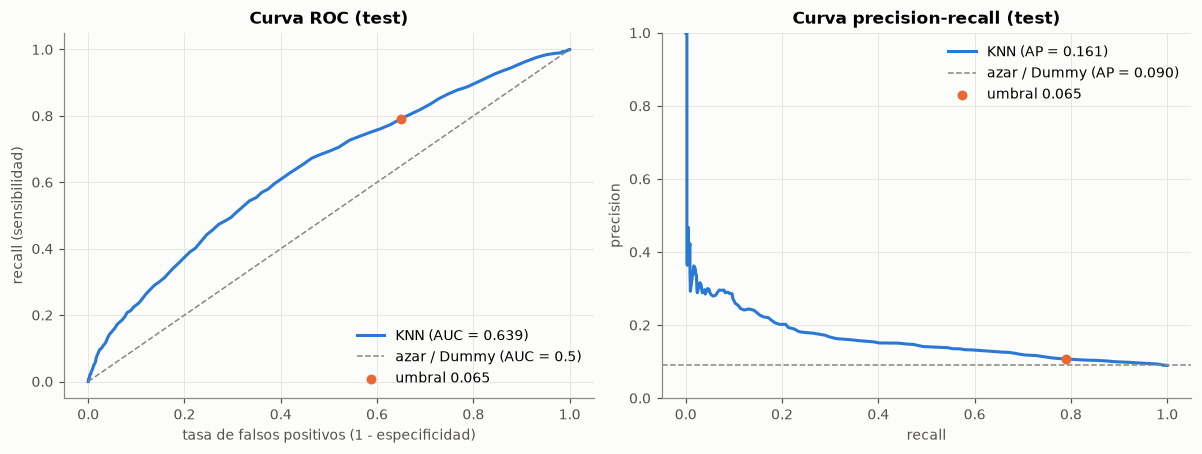

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
fpr, tpr, thr_roc = roc_curve(y_test, proba)
auc = roc_auc_score(y_test, proba)
axes[0].plot(fpr, tpr, color=C[0], lw=2, label=f'KNN (AUC = {auc:.3f})')
axes[0].plot([0, 1], [0, 1], color=MUTED, ls='--', lw=1, label='azar / Dummy (AUC = 0.5)')
i_t = np.argmin(np.abs(thr_roc - UMBRAL))
axes[0].scatter(fpr[i_t], tpr[i_t], color=C[1], zorder=3, s=30, label=f'umbral {UMBRAL:.3f}')
axes[0].set_xlabel('tasa de falsos positivos (1 - especificidad)'); axes[0].set_ylabel('recall (sensibilidad)')
axes[0].set_title('Curva ROC (test)'); axes[0].legend(frameon=False, loc='lower right')

p_t, r_t, thr_pr = precision_recall_curve(y_test, proba)
ap = average_precision_score(y_test, proba)
axes[1].plot(r_t, p_t, color=C[0], lw=2, label=f'KNN (AP = {ap:.3f})')
axes[1].axhline(y_test.mean(), color=MUTED, ls='--', lw=1, label=f'azar / Dummy (AP = {y_test.mean():.3f})')
axes[1].scatter(recall_score(y_test, pred_t), precision_score(y_test, pred_t), color=C[1], zorder=3, s=30,
                label=f'umbral {UMBRAL:.3f}')
axes[1].set_xlabel('recall'); axes[1].set_ylabel('precision'); axes[1].set_ylim(0, 1)
axes[1].set_title('Curva precision-recall (test)'); axes[1].legend(frameon=False, loc='upper right')
plt.tight_layout(); plt.show()

**Lectura de los resultados en test** (1 257 pacientes reingresaron en menos de 30 días):
- **Umbral 0.5 = inútil:** ninguna probabilidad llega a 0.5 (la máxima ronda 0.23), así que el KNN por defecto es idéntico al Dummy: **deja pasar los 1 257 reingresos**.
- **Criterio anterior (máx. F1, umbral 0.098):** detecta 608 y **deja pasar 649** (52 %). Demasiados para un problema donde el falso negativo es el error grave.
- **Criterio elegido (recall ≥ 80 %, umbral 0.065):** detecta **994 (79.1 %)** y deja pasar **263**, es decir, 386 reingresos menos sin detectar que con F1. El objetivo se fijó en train (80.9 % en OOF) y en test da 79.1 %: prácticamente lo mismo, no hay sobreajuste del umbral.
- **El precio:** para lograrlo hay que marcar al **66 % de los pacientes** (9 260 de 13 998), con 8 266 falsas alarmas. Solo **1 de cada 9 alertas** es un reingreso real (precision 0.107).
- **¿Cuánto aporta el modelo?** Marcando **al azar** la misma cantidad de pacientes (66 %) se detectarían ~857 reingresos (68 %) y se dejarían pasar 400. El KNN detecta **137 más** con la misma carga de trabajo: aporta, pero la ventaja sobre el azar es modesta, porque la señal de los datos es débil (AUC 0.639).
- **Marcar a todos** detecta el 100 %, pero entonces el modelo no sirve para priorizar. El KNN es útil en la medida en que **deja fuera a un tercio de los pacientes** (los de menor riesgo) perdiendo solo el 21 % de los reingresos.
- La tabla de la sección 5 permite elegir otro punto: con recall ≥ 70 % se marca el 54 % de los pacientes; con recall ≥ 90 %, el 80 %. Cuántas alertas se pueden atender es una decisión del hospital, no del modelo.

### 6.1 Intervalos de confianza (bootstrap)

Un solo número en test (AUC = 0.639) no dice cuánto podría variar con otra muestra de pacientes. Con **bootstrap** re-muestreamos el test 1 000 veces (con reemplazo) y recalculamos cada métrica: el intervalo entre los percentiles 2.5 y 97.5 es el **IC 95 %**. Así sabemos qué diferencias son reales y cuáles son ruido.

In [17]:
rng = np.random.default_rng(RS)
N_BOOT = 1000
yt = y_test.to_numpy()

def ic_bootstrap(fn, *scores):
    vals = []
    for _ in range(N_BOOT):
        i = rng.integers(0, len(yt), len(yt))
        if yt[i].min() == yt[i].max():
            continue
        vals.append(fn(yt[i], *[s[i] for s in scores]))
    return np.percentile(vals, [2.5, 97.5])

ic = pd.DataFrame({
    'ROC-AUC': [roc_auc_score(yt, proba), *ic_bootstrap(roc_auc_score, proba)],
    'Avg. precision': [average_precision_score(yt, proba), *ic_bootstrap(average_precision_score, proba)],
    f'Recall (umbral {UMBRAL:.3f})': [recall_score(yt, pred_t), *ic_bootstrap(lambda a, b: recall_score(a, b), pred_t)],
    f'Precision (umbral {UMBRAL:.3f})': [precision_score(yt, pred_t), *ic_bootstrap(lambda a, b: precision_score(a, b), pred_t)],
}, index=['valor', 'IC 2.5 %', 'IC 97.5 %']).T
ic.round(3)

,valor,IC 2.5 %,IC 97.5 %
ROC-AUC,0.639,0.624,0.656
Avg. precision,0.161,0.146,0.179
Recall (umbral 0.065),0.791,0.767,0.813
Precision (umbral 0.065),0.107,0.101,0.114


- **AUC = 0.639, IC 95 % [0.624, 0.656]:** el intervalo mide ±0.016. Por eso diferencias de AUC menores a ~0.01 entre variantes (por ejemplo, entre valores de k de la meseta, o el +0.007 de agregar `diag_1`) **están dentro del ruido** y no deben interpretarse como mejoras reales.
- **Recall con umbral 0.065 = 0.791, IC [0.767, 0.813]:** el objetivo de 80 % elegido en train se cumple dentro del margen de error.
- **Precision = 0.107, IC [0.101, 0.114]:** de forma robusta, ~1 de cada 9 alertas es un reingreso real.

### 6.2 Calibración: ¿las probabilidades significan riesgo real?

AUC solo mide si el modelo **ordena** bien a los pacientes. En un modelo de riesgo clínico también importa que la probabilidad sea **creíble**: si el modelo dice “12 %”, entre esos pacientes deberían reingresar ~12 %. Eso se llama **calibración** y se revisa así:
- **Curva de calibración:** agrupamos a los pacientes en 10 grupos (deciles) según su probabilidad y comparamos la probabilidad media predicha con la tasa real de reingreso. Un modelo bien calibrado queda sobre la diagonal.
- **Brier score:** error cuadrático medio de la probabilidad (menor es mejor). Lo comparamos con el Brier de predecir siempre la prevalencia (un modelo que no sabe nada).

Si el KNN está mal calibrado, lo **recalibramos** con una regresión isotónica ajustada sobre las probabilidades *out-of-fold* de train (así el test sigue sin tocarse). La isotónica es una función monótona: **no cambia el orden** de los pacientes (el AUC queda casi igual), solo corrige la escala.

In [18]:
iso = IsotonicRegression(out_of_bounds='clip').fit(oof, y_train)
proba_cal = iso.predict(proba)

def tabla_deciles(score):
    t = pd.DataFrame({'pred': score, 'obs': yt})
    t['decil'] = pd.qcut(t['pred'].rank(method='first'), 10, labels=range(1, 11))
    return t.groupby('decil', observed=True)[['pred', 'obs']].mean()

dec_raw, dec_cal = tabla_deciles(proba), tabla_deciles(proba_cal)
brier = pd.Series({
    'Prevalencia (sin modelo)': brier_score_loss(yt, np.full(len(yt), y_train.mean())),
    'KNN (original)': brier_score_loss(yt, proba),
    'KNN (recalibrado)': brier_score_loss(yt, proba_cal),
}, name='Brier score (test)')
display(brier.round(5).to_frame())
comp_dec = pd.concat({'KNN original': dec_raw, 'KNN recalibrado': dec_cal}, axis=1)
comp_dec.round(3)

,Brier score (test)
Prevalencia (sin modelo),0.08173
KNN (original),0.07999
KNN (recalibrado),0.07963


KNN original        KNN recalibrado       
              pred    obs            pred    obs
decil                                           
1            0.038  0.039           0.039  0.039
2            0.050  0.062           0.048  0.059
3            0.058  0.063           0.058  0.065
4            0.065  0.061           0.068  0.061
5            0.072  0.059           0.072  0.059
6            0.081  0.086           0.084  0.089
7            0.091  0.096           0.094  0.093
8            0.103  0.117           0.117  0.119
9            0.117  0.121           0.138  0.124
10           0.145  0.194           0.185  0.191

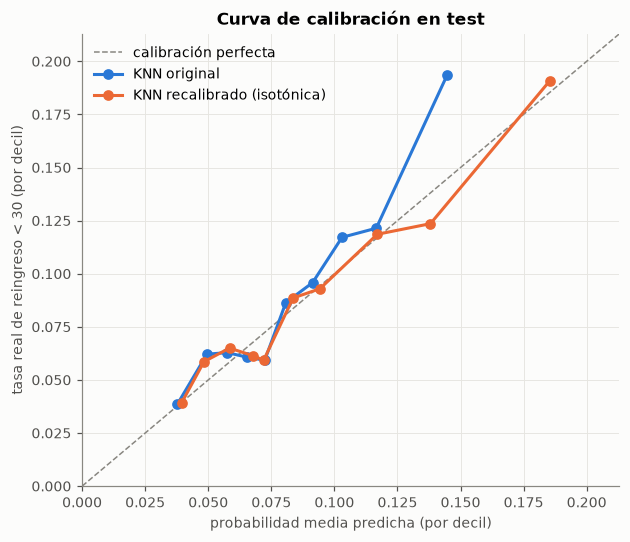

In [19]:
fig, ax = plt.subplots(figsize=(5.8, 5))
lim = max(dec_raw.max().max(), dec_cal.max().max()) * 1.1
ax.plot([0, lim], [0, lim], color=MUTED, ls='--', lw=1, label='calibración perfecta')
ax.plot(dec_raw['pred'], dec_raw['obs'], marker='o', ms=6, lw=2, color=C[0], label='KNN original')
ax.plot(dec_cal['pred'], dec_cal['obs'], marker='o', ms=6, lw=2, color=C[1], label='KNN recalibrado (isotónica)')
ax.set_xlim(0, lim); ax.set_ylim(0, lim)
ax.set_xlabel('probabilidad media predicha (por decil)'); ax.set_ylabel('tasa real de reingreso < 30 (por decil)')
ax.set_title('Curva de calibración en test')
ax.legend(frameon=False, loc='upper left')
plt.tight_layout(); plt.show()

- **El KNN original subestima el riesgo de los pacientes más riesgosos:** en el decil 10 predice 14.5 % y reingresa el **19.4 %**. Con k = 676 las probabilidades se “aplastan” hacia el promedio: al promediar tantos vecinos, casi nadie puede recibir un riesgo alto. En los deciles 1–9 el error es pequeño.
- **Después de recalibrar** (isotónica ajustada solo con train), el decil 10 predice **18.5 %** contra 19.1 % real y la curva queda cerca de la diagonal en todo el rango. El AUC no cambia (la isotónica respeta el orden).
- **Brier:** 0.0800 (original) y 0.0796 (recalibrado) contra 0.0817 de predecir siempre la prevalencia. La mejora sobre “no saber nada” es de apenas ~2.5 %: es otra forma de ver que la señal de los datos es débil.
- **Consecuencia práctica:** para comunicar riesgo (“este paciente tiene 18 % de probabilidad de volver”) hay que usar las probabilidades **recalibradas**. El umbral de la sección 5 se eligió sobre las originales; como la isotónica no cambia el orden, la selección de pacientes es la misma.

### 6.3 Comparación con modelos de referencia

KNN no es el modelo que usa la literatura para este problema. Para saber si nos estamos quedando atrás, lo comparamos en **el mismo split** con:
- **Regresión logística** con las mismas features y el mismo preprocesamiento (el estándar clínico);
- **HistGradientBoosting con las mismas variables** (para separar el efecto del algoritmo) y **con todas** las variables del dataset limpio (los árboles no sufren con muchas columnas ni necesitan escalar; las categóricas se usan directamente).

La diferencia de AUC se evalúa con **bootstrap pareado** (los mismos pacientes re-muestreados para todos los modelos), así sabemos si es real o ruido. También medimos el **recall por capacidad**: si el hospital solo puede hacer seguimiento al 10 %, 20 % o 30 % de los pacientes con mayor riesgo, ¿qué fracción de los reingresos atrapa cada modelo?

In [20]:
t = time.time()
logreg = Pipeline([('pre', hacer_preproceso(NUM, CAT)), ('lr', LogisticRegression(max_iter=2000))])
logreg.fit(X_train, y_train)
proba_lr = logreg.predict_proba(X_test)[:, 1]

# HGB: todas las variables del CSV limpio, sin IDs, objetivos ni versiones duplicadas
excluir = ['patient_nbr', 'readmitted', 'readmitted_30', 'age', 'number_outpatient_log', 'number_emergency_log',
           'number_inpatient_log', 'alta_grupo', 'diag_1_grp', 'origen_grupo', 'diag_2_grp', 'diag_3_grp']
X_all = df.drop(columns=excluir, errors='ignore')
cat_cols = X_all.select_dtypes(exclude='number').columns
X_all[cat_cols] = X_all[cat_cols].astype('category')
hgb = HistGradientBoostingClassifier(categorical_features='from_dtype', early_stopping=True, random_state=RS)
hgb.fit(X_all.loc[X_train.index], y_train)
proba_hgb = hgb.predict_proba(X_all.loc[X_test.index])[:, 1]
print(f'Entrenamiento LR + HGB: {time.time() - t:.0f} s | HGB usa {X_all.shape[1]} variables')

# HGB con las MISMAS variables del KNN: separa el efecto del algoritmo del efecto de tener más variables
X_mismas = df[NUM + CAT].copy()
X_mismas[CAT] = X_mismas[CAT].astype('category')
hgb_mismas = HistGradientBoostingClassifier(categorical_features='from_dtype', early_stopping=True, random_state=RS)
hgb_mismas.fit(X_mismas.loc[X_train.index], y_train)
proba_hgb_mismas = hgb_mismas.predict_proba(X_mismas.loc[X_test.index])[:, 1]

MODELOS = {'KNN': proba, 'Regresión logística': proba_lr,
           'HistGradientBoosting (mismas variables)': proba_hgb_mismas, 'HistGradientBoosting (todas)': proba_hgb}
rng = np.random.default_rng(RS)   # misma semilla que la sección 6.1: el IC del KNN coincide con el de 6.1

def recall_capacidad(score, q):
    corte = np.quantile(score, 1 - q)
    return yt[score >= corte].sum() / yt.sum()

filas = []
for nombre, s in MODELOS.items():
    lo, hi = ic_bootstrap(roc_auc_score, s)
    filas.append({'modelo': nombre, 'ROC-AUC': roc_auc_score(yt, s), 'IC 95 %': f'[{lo:.3f}, {hi:.3f}]',
                  'Avg. precision': average_precision_score(yt, s), 'Brier': brier_score_loss(yt, s),
                  'recall top 10 %': recall_capacidad(s, 0.10), 'recall top 20 %': recall_capacidad(s, 0.20),
                  'recall top 30 %': recall_capacidad(s, 0.30)})
tabla_ref = pd.DataFrame(filas).set_index('modelo')
display(tabla_ref.round(3))

# diferencia pareada de AUC contra KNN
difs = {}
for nombre in ['Regresión logística', 'HistGradientBoosting (mismas variables)', 'HistGradientBoosting (todas)']:
    lo, hi = ic_bootstrap(lambda a, b, c: roc_auc_score(a, b) - roc_auc_score(a, c), MODELOS[nombre], proba)
    difs[f'{nombre} − KNN'] = {'ΔAUC': roc_auc_score(yt, MODELOS[nombre]) - roc_auc_score(yt, proba),
                               'IC 2.5 %': lo, 'IC 97.5 %': hi, '¿significativa?': 'sí' if lo > 0 or hi < 0 else 'no'}
pd.DataFrame(difs).T

Entrenamiento LR + HGB: 1 s | HGB usa 32 variables


,ROC-AUC,IC 95 %,Avg. precision,Brier,recall top 10 %,recall top 20 %,recall top 30 %
modelo,,,,,,,
KNN,0.639,"[0.624, 0.656]",0.161,0.080,0.225,0.359,0.484
Regresión logística,0.645,"[0.628, 0.660]",0.168,0.079,0.231,0.371,0.496
HistGradientBoosting (mismas variables),0.644,"[0.626, 0.661]",0.171,0.079,0.228,0.361,0.484
HistGradientBoosting (todas),0.653,"[0.637, 0.670]",0.187,0.079,0.247,0.387,0.499


,ΔAUC,IC 2.5 %,IC 97.5 %,¿significativa?
Regresión logística − KNN,0.005453,-0.002347,0.012663,no
HistGradientBoosting (mismas variables) − KNN,0.004568,-0.004029,0.012767,no
HistGradientBoosting (todas) − KNN,0.014304,0.00444,0.02436,sí


- **Regresión logística empata con el KNN:** AUC 0.645 contra 0.639; la diferencia (+0.005, IC [−0.002, 0.013]) **no es significativa**. Es más simple, más rápida y da coeficientes interpretables; su Brier es apenas menor (0.0793 contra 0.0800).
- **Gradient boosting con las mismas variables del KNN también empata:** AUC 0.644 (+0.005, IC [−0.004, 0.013], no significativa). Es decir, **cambiar el algoritmo no mejora el resultado**.
- **Gradient boosting con todas las variables sí es mejor:** AUC 0.653 (+0.014, IC [0.004, 0.024], **significativa**) y average precision 0.187 contra 0.161. La mejora viene de **usar más variables**, que los árboles aprovechan y que al KNN le hacen daño (sección 7.2).
- **Con capacidad limitada** la diferencia es pequeña pero consistente: haciendo seguimiento al 20 % de mayor riesgo, el KNN atrapa el **35.9 %** de los reingresos, la regresión logística el 37.1 % y el gradient boosting con todas las variables el **38.7 %**.
- **Contexto de la literatura:** con un paciente por fila (sin fuga), los trabajos publicados sobre este dataset obtienen AUC de ~0.62 a 0.67 para `<30` (por ejemplo, Liu, Sue & Wu 2024: XGBoost 0.64, RF 0.63). El KNN está **dentro del rango esperado**; con las mismas variables todos los modelos rinden igual, así que el techo lo ponen las variables disponibles, no el algoritmo.

### 6.4 Curva de decisión: ¿cuánto vale usar el modelo?

Elegir un umbral es aceptar un **intercambio**: con umbral *p*, estamos diciendo que estamos dispuestos a tolerar **como máximo** *(1 − p) / p* falsas alarmas por cada reingreso detectado (un reingreso detectado “vale” lo mismo que (1 − p)/p seguimientos innecesarios). Con el umbral de la sección 5 (**0.065**) eso es **≈ 14 : 1**: aceptamos hasta 14 seguimientos innecesarios por cada reingreso que atrapamos. Es un máximo tolerable, no lo que ocurre: en test, con ese umbral, la razón observada fue **8.3** falsas alarmas por reingreso detectado (8 266 / 994). Es razonable si el seguimiento es barato (una llamada, un control), y no lo sería si fuera caro o invasivo.

El **beneficio neto** (Vickers & Elkin, 2006) resume esto en un número para cada umbral:

$$\text{beneficio neto}(p) = \frac{VP}{n} - \frac{FP}{n}\cdot\frac{p}{1-p}$$

Se compara contra dos estrategias sin modelo: **hacer seguimiento a todos** y **a nadie** (beneficio 0). Un modelo solo sirve en los umbrales donde su curva queda **por encima de ambas**. Para el KNN usamos las probabilidades **recalibradas**, porque el umbral tiene que significar riesgo real.

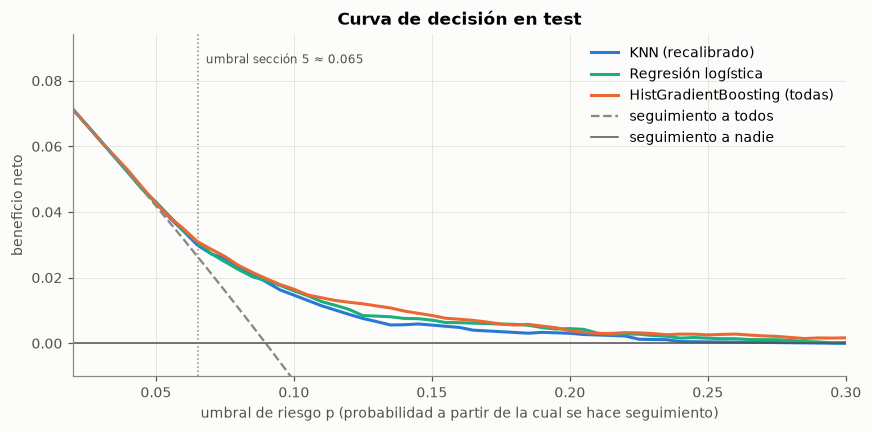

,KNN (recalibrado) (por 1000 pac.),Regresión logística (por 1000 pac.),HistGradientBoosting (todas) (por 1000 pac.),seguimiento a todos (por 1000 pac.)
umbral,,,,
0.050,42.8,43.1,42.7,41.9
0.065,30.0,30.9,31.0,26.5
0.100,14.7,16.0,16.5,-11.3
0.150,5.6,7.1,8.5,-70.8
0.200,3.1,4.5,3.8,-137.8


In [21]:
umbrales = np.linspace(0.02, 0.30, 57)
prev = yt.mean()

def beneficio_neto(score, pt):
    pred = score >= pt
    vp = (pred & (yt == 1)).sum() / len(yt)
    fp = (pred & (yt == 0)).sum() / len(yt)
    return vp - fp * pt / (1 - pt)

curvas = {
    'KNN (recalibrado)': [beneficio_neto(proba_cal, u) for u in umbrales],
    'Regresión logística': [beneficio_neto(proba_lr, u) for u in umbrales],
    'HistGradientBoosting (todas)': [beneficio_neto(proba_hgb, u) for u in umbrales],
}
todos = [prev - (1 - prev) * u / (1 - u) for u in umbrales]

fig, ax = plt.subplots(figsize=(8, 4))
for (nombre, v), col in zip(curvas.items(), [C[0], C[2], C[1]]):
    ax.plot(umbrales, v, lw=2, color=col, label=nombre)
ax.plot(umbrales, todos, color=MUTED, lw=1.5, ls='--', label='seguimiento a todos')
ax.axhline(0, color=INK, lw=1, label='seguimiento a nadie')
ax.axvline(UMBRAL, color=MUTED, ls=':', lw=1)
ax.text(UMBRAL + 0.003, prev * 0.95, f'umbral sección 5 ≈ {UMBRAL:.3f}', color=INK, fontsize=8)
ax.set_ylim(-0.01, prev * 1.05); ax.set_xlim(umbrales[0], umbrales[-1])
ax.set_xlabel('umbral de riesgo p (probabilidad a partir de la cual se hace seguimiento)')
ax.set_ylabel('beneficio neto')
ax.set_title('Curva de decisión en test')
ax.legend(frameon=False, loc='upper right')
plt.tight_layout(); plt.show()

nb_tabla = pd.DataFrame({k: v for k, v in curvas.items()}, index=umbrales.round(3))
nb_tabla['seguimiento a todos'] = todos
(nb_tabla.loc[[0.05, 0.065, 0.1, 0.15, 0.2]] * 1000).round(1).rename_axis('umbral').rename(
    columns=lambda c: c + ' (por 1000 pac.)')

- **Con el umbral de la sección 5 (0.065), el KNN aporta 30.0 casos netos por cada 1 000 pacientes, contra 26.5 de hacer seguimiento a todos:** una ganancia real pero pequeña (~3.5 por cada 1 000). A ese umbral los tres modelos son prácticamente iguales (30.0–31.0).
- **La ventaja del modelo crece cuando el seguimiento es más caro.** Con umbral 0.10 (aceptar hasta 9 falsas alarmas por reingreso), “seguimiento a todos” ya es **negativo** (−11.3), mientras el KNN sigue en +14.7 y el gradient boosting en +16.5. Con umbrales ≥ 0.20 casi ningún modelo aporta: hay muy pocos pacientes con riesgo tan alto.
- **Cómo usar esto:** el umbral no debería salir de “quiero 80 % de recall”, sino de **cuánto cuesta el seguimiento frente a un reingreso no detectado**. Si una llamada de control es barata, un umbral bajo (0.05–0.07, recall ~80 %) es defendible, y es el que usamos. Si el seguimiento fuera una visita domiciliaria cara, convendría un umbral de ~0.10–0.15 y marcar a muchos menos pacientes.

## 7. ¿Ayudan las variables categóricas?

Comparamos, con los mismos hiperparámetros (`k`, `weights`, `metric`) y la misma CV de 5 folds sobre train:
- **solo numéricas** (8 columnas);
- **numéricas + destino al alta** agrupado;
- **numéricas + destino al alta + `diag_1`** (el modelo final).

Así vemos si las dummies aportan señal o solo agregan ruido a la distancia.

In [22]:
variantes = {
    'solo numéricas (8)': (NUM, []),
    'numéricas + alta_grupo': (NUM, ['alta_grupo']),
    'numéricas + alta_grupo + diag_1': (NUM, CAT),
}
filas = []
t = time.time()
for nombre, (nu, ca) in variantes.items():
    p = Pipeline([('pre', hacer_preproceso(nu, ca)),
                  ('knn', KNeighborsClassifier(n_neighbors=BEST_K, weights=bp['knn__weights'], metric=bp['knn__metric']))])
    s = cross_validate(p, X_train, y_train, cv=cv, scoring={'auc': 'roc_auc', 'ap': 'average_precision'}, n_jobs=-1)
    filas.append({'variante': nombre, 'AUC_CV': s['test_auc'].mean(), 'AUC_std': s['test_auc'].std(),
                  'AP_CV': s['test_ap'].mean()})
comp = pd.DataFrame(filas).set_index('variante')
print(f'Tiempo: {time.time() - t:.0f} s')
comp.round(4)

Tiempo: 47 s


,AUC_CV,AUC_std,AP_CV
variante,,,
solo numéricas (8),0.6056,0.0050,0.1348
numéricas + alta_grupo,0.6328,0.0058,0.1522
numéricas + alta_grupo + diag_1,0.6397,0.0038,0.1543


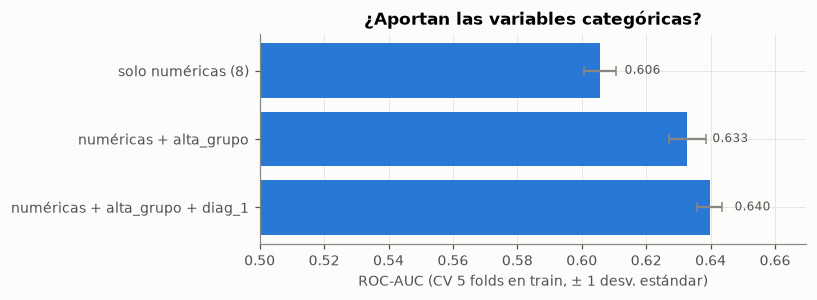

In [23]:
fig, ax = plt.subplots(figsize=(7.5, 2.8))
ax.barh(comp.index, comp['AUC_CV'], xerr=comp['AUC_std'], color=C[0], ecolor=MUTED, capsize=3)
for i, v in enumerate(comp['AUC_CV']):
    ax.text(v + comp['AUC_std'].max() + 0.002, i, f'{v:.3f}', va='center', color=INK, fontsize=8)
ax.set_xlim(0.5, comp['AUC_CV'].max() + 0.03)
ax.invert_yaxis()
ax.set_xlabel('ROC-AUC (CV 5 folds en train, ± 1 desv. estándar)')
ax.set_title('¿Aportan las variables categóricas?')
plt.tight_layout(); plt.show()

**Las categóricas sí ayudan**, a pesar de sumar 16 dummies a la distancia:
- Solo numéricas: AUC = **0.606**.
- + destino al alta agrupado: **0.633** (+0.027, el salto más grande).
- + `diag_1`: **0.640** (+0.007 adicional, pequeño pero mayor que la desviación entre folds).

El destino al alta aporta información que ninguna numérica tiene (por ejemplo, ir a rehabilitación). Esto también confirma que **agrupar** valió la pena: 7 dummies bien pobladas en vez de 20 casi vacías.

### 7.2 ¿Y las variables que recomienda la literatura?

La literatura sobre este dataset (Strack et al. 2014 y trabajos posteriores) destaca otras variables que el KNN no usa: **origen de la admisión**, **`diag_2` y `diag_3`**, **HbA1c**, **insulina**, **especialidad médica** y **número de procedimientos**. Probamos agregarlas una por una (y todas juntas) con el mismo k y la misma CV de 5 folds en train. El origen de la admisión se agrupa en 4 categorías (urgencias / derivación / traslado / otro).

In [24]:
def agrupar_origen(s):
    if s == 'Emergency Room':
        return 'Urgencias'
    if 'Referral' in s:
        return 'Derivación'
    if 'Transfer' in s:
        return 'Traslado'
    return 'Otro / Desconocido'

df['origen_grupo'] = df['admission_source_id'].map(agrupar_origen)
for c in ['diag_2', 'diag_3']:
    df[c + '_grp'] = df[c].replace({'Desconocido': 'Otros'})

EXTRA = {
    'actual (8 num. + alta + diag_1)': (NUM, CAT),
    '+ origen de la admisión': (NUM, CAT + ['origen_grupo']),
    '+ diag_2 y diag_3': (NUM, CAT + ['diag_2_grp', 'diag_3_grp']),
    '+ HbA1c e insulina': (NUM, CAT + ['A1Cresult', 'insulin']),
    '+ especialidad médica': (NUM, CAT + ['medical_specialty']),
    '+ num_procedures': (NUM + ['num_procedures'], CAT),
    'todas las anteriores': (NUM + ['num_procedures'],
                             CAT + ['origen_grupo', 'diag_2_grp', 'diag_3_grp', 'A1Cresult', 'insulin', 'medical_specialty']),
}
filas = []
t = time.time()
for nombre, (nu, ca) in EXTRA.items():
    p = Pipeline([('pre', hacer_preproceso(nu, ca)),
                  ('knn', KNeighborsClassifier(n_neighbors=BEST_K, weights=bp['knn__weights'], metric=bp['knn__metric']))])
    s = cross_validate(p, df.loc[X_train.index, nu + ca], y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
    n_col = hacer_preproceso(nu, ca).fit(df.loc[X_train.index[:2000], nu + ca]).transform(df.loc[X_train.index[:5], nu + ca]).shape[1]
    filas.append({'variante': nombre, 'columnas': n_col, 'AUC_CV': s['test_score'].mean(), 'AUC_std': s['test_score'].std()})
lit_knn = pd.DataFrame(filas).set_index('variante')
print(f'Tiempo: {time.time() - t:.0f} s')
lit_knn.round(4)

Tiempo: 131 s


,columnas,AUC_CV,AUC_std
variante,,,
actual (8 num. + alta + diag_1),24,0.6397,0.0038
+ origen de la admisión,28,0.6363,0.0034
+ diag_2 y diag_3,42,0.6345,0.0058
+ HbA1c e insulina,32,0.6369,0.0048
+ especialidad médica,36,0.6396,0.0043
+ num_procedures,25,0.6407,0.0041
todas las anteriores,67,0.6344,0.0074


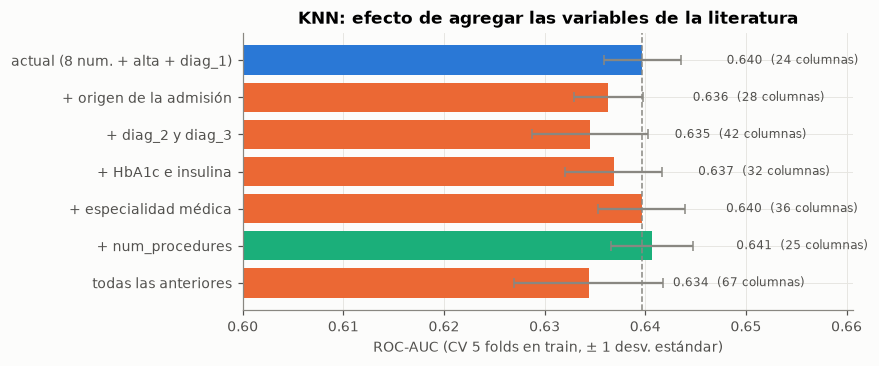

In [25]:
fig, ax = plt.subplots(figsize=(8, 3.4))
colores = [C[0] if i == 0 else (C[1] if v < lit_knn['AUC_CV'].iloc[0] else C[2]) for i, v in enumerate(lit_knn['AUC_CV'])]
ax.barh(lit_knn.index, lit_knn['AUC_CV'], xerr=lit_knn['AUC_std'], color=colores, ecolor=MUTED, capsize=3)
for i, (v, n) in enumerate(zip(lit_knn['AUC_CV'], lit_knn['columnas'])):
    ax.text(v + lit_knn['AUC_std'].max() + 0.001, i, f'{v:.3f}  ({n} columnas)', va='center', color=INK, fontsize=8)
ax.axvline(lit_knn['AUC_CV'].iloc[0], color=MUTED, ls='--', lw=1)
ax.set_xlim(0.60, lit_knn['AUC_CV'].max() + 0.02); ax.invert_yaxis()
ax.set_xlabel('ROC-AUC (CV 5 folds en train, ± 1 desv. estándar)')
ax.set_title('KNN: efecto de agregar las variables de la literatura')
plt.tight_layout(); plt.show()

En azul la versión actual; en naranja las variantes que **empeoran** el AUC, y en verde la que lo mejora.

- **Agregar las variables de la literatura no ayuda al KNN; en general lo empeora.** Con todas juntas (67 columnas) el AUC baja de 0.640 a 0.634. Solo `num_procedures` mejora apenas (0.641), dentro del ruido.
- **¿Por qué, si en gradient boosting sí ayudan?** En KNN **cada columna pesa igual en la distancia**, sea útil o no. Cada dummy nueva agrega diferencias entre pacientes que casi no tienen relación con el reingreso, y eso “diluye” a las variables que sí importan (visitas previas, destino al alta). Los árboles, en cambio, **eligen** qué variables usar en cada división e ignoran las que no sirven.
- **Conclusión:** para KNN conviene un conjunto **corto y seleccionado** de variables. Es una limitación estructural del método con datos mixtos y muchas categorías; alternativas serían ponderar las variables (aprender un peso por columna) o usar distancias para datos mixtos como Gower.

## 8. (Extra) KNN con las 3 clases originales

Solo como comparación: mismo pipeline e hiperparámetros, pero con `readmitted` (`<30`, `>30`, `NO`) como objetivo. Evaluamos en el mismo test (mismas filas) con AUC *one-vs-rest* por clase y balanced accuracy.

In [26]:
y3_train = df.loc[X_train.index, 'readmitted']
y3_test = df.loc[X_test.index, 'readmitted']
print(y3_train.value_counts(normalize=True).round(3).to_dict())

knn3 = Pipeline([('pre', hacer_preproceso(NUM, CAT)),
                 ('knn', KNeighborsClassifier(n_neighbors=BEST_K, weights=bp['knn__weights'], metric=bp['knn__metric']))])
knn3.fit(X_train, y3_train)
proba3 = knn3.predict_proba(X_test)
clases = knn3.classes_
pred3 = knn3.predict(X_test)

auc_ovr = {c: roc_auc_score((y3_test == c).astype(int), proba3[:, i]) for i, c in enumerate(clases)}
print('AUC one-vs-rest por clase:', {k: round(v, 3) for k, v in auc_ovr.items()})
print(f'AUC macro OvR: {roc_auc_score(y3_test, proba3, multi_class="ovr", average="macro"):.3f}')
print(f'Balanced accuracy (argmax): {balanced_accuracy_score(y3_test, pred3):.3f}   (azar = 0.333)')
print('Predicciones (argmax):', pd.Series(pred3).value_counts().to_dict())
pd.crosstab(y3_test.values, pred3, rownames=['real'], colnames=['predicho'])

{'NO': 0.593, '>30': 0.317, '<30': 0.09}


AUC one-vs-rest por clase: {'<30': 0.639, '>30': 0.622, 'NO': 0.641}
AUC macro OvR: 0.634
Balanced accuracy (argmax): 0.350   (azar = 0.333)
Predicciones (argmax): {'NO': 13391, '>30': 607}


predicho,>30,NO
real,,
<30,112,1145
>30,321,4129
NO,174,8117


Con 3 clases el problema se vuelve peor planteado para KNN: el modelo **nunca predice `<30`** (con argmax gana casi siempre `NO`, la clase mayoritaria del 59 %) y la balanced accuracy es **0.350**, apenas sobre el azar (0.333). El AUC one-vs-rest de `<30` (0.639) es el mismo que en el modelo binario, y el de `>30` es incluso más bajo (0.622): separar `>30` de `NO` no agrega señal útil. Esto respalda la decisión de trabajar con el objetivo binario.

## 9. Propuesta de uso: seguimiento en dos niveles

Un modelo de riesgo solo sirve si cambia **qué se hace** con cada paciente al alta. Proponemos dos intervenciones de distinto costo:

| Nivel | Intervención | Costo | Para quién |
|---|---|---|---|
| **Alto** | **Cita presencial** de control en los días siguientes al alta | alto | pacientes con mayor riesgo |
| **Medio** | **Teleconsulta** (llamada o videollamada de seguimiento) | bajo | riesgo intermedio |
| **Bajo** | alta habitual, sin seguimiento extra | 0 | resto |

La idea: **lo caro, solo para quienes más lo necesitan; lo barato, más amplio**. Así se reduce el costo de las falsas alarmas (la preocupación de marcar a demasiados pacientes) sin abandonar a los de riesgo intermedio.

### 9.1 Propuesta base: por capacidad

Definimos los niveles por **capacidad**, que es como suele planificar un hospital: **cita presencial para el 10 %** de pacientes con mayor riesgo y **teleconsulta para el siguiente 20 %**. En total se contacta al **30 %** (31.4 % en test, porque los cortes se fijan en train), la misma carga que el umbral de máx. F1 de la sección 5. Los cortes se calculan con las probabilidades *out-of-fold* de **train** y se aplican al test.

In [27]:
TOP_PRESENCIAL = 0.10   # fracción de pacientes con cita presencial
TOP_TOTAL = 0.30        # fracción total contactada (presencial + teleconsulta)

U_PRES = float(np.quantile(oof, 1 - TOP_PRESENCIAL))
U_TELE = float(np.quantile(oof, 1 - TOP_TOTAL))
print(f'Corte cita presencial: probabilidad KNN >= {U_PRES:.3f} | corte teleconsulta: >= {U_TELE:.3f}')

ORDEN_NIV = ['Cita presencial', 'Teleconsulta', 'Sin seguimiento']
def niveles(score, u_pres, u_tele):
    return np.where(score >= u_pres, 'Cita presencial', np.where(score >= u_tele, 'Teleconsulta', 'Sin seguimiento'))

niv = pd.DataFrame({'nivel': niveles(proba, U_PRES, U_TELE), 'reingreso': yt, 'riesgo': proba_cal})
tabla_niv = niv.groupby('nivel').agg(pacientes=('reingreso', 'size'), reingresos=('reingreso', 'sum'),
                                     tasa_real=('reingreso', 'mean'), riesgo_predicho=('riesgo', 'mean')).reindex(ORDEN_NIV)
tabla_niv['% pacientes'] = tabla_niv['pacientes'] / len(niv) * 100
tabla_niv['% de los reingresos'] = tabla_niv['reingresos'] / yt.sum() * 100
tabla_niv['contactos por reingreso'] = tabla_niv['pacientes'] / tabla_niv['reingresos']
tabla_niv.round(3)

Corte cita presencial: probabilidad KNN >= 0.124 | corte teleconsulta: >= 0.096


,pacientes,reingresos,tasa_real,riesgo_predicho,% pacientes,% de los reingresos,contactos por reingreso
nivel,,,,,,,
Cita presencial,1494,283,0.189,0.183,10.673,22.514,5.279
Teleconsulta,2905,338,0.116,0.125,20.753,26.889,8.595
Sin seguimiento,9599,636,0.066,0.066,68.574,50.597,15.093


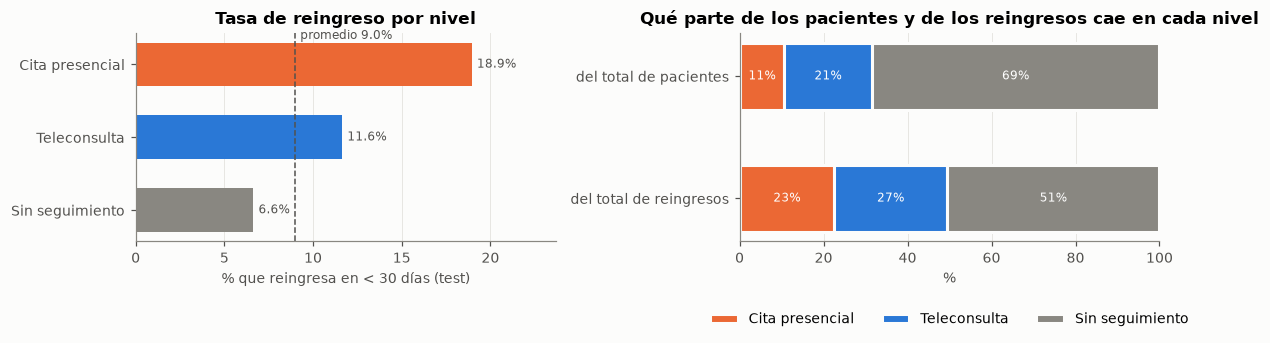

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
col_niv = {'Cita presencial': C[1], 'Teleconsulta': C[0], 'Sin seguimiento': MUTED}
t = tabla_niv.iloc[::-1]
axes[0].barh(t.index, t['tasa_real'] * 100, color=[col_niv[i] for i in t.index], height=0.6)
axes[0].axvline(yt.mean() * 100, color=INK, ls='--', lw=1)
axes[0].text(yt.mean() * 100 + 0.3, 2.35, f'promedio {yt.mean():.1%}', color=INK, fontsize=8)
for i, v in enumerate(t['tasa_real']):
    axes[0].text(v * 100 + 0.3, i, f'{v:.1%}', va='center', color=INK, fontsize=8)
axes[0].set_xlabel('% que reingresa en < 30 días (test)'); axes[0].set_title('Tasa de reingreso por nivel')
axes[0].set_xlim(0, t['tasa_real'].max() * 100 * 1.25); axes[0].grid(axis='y', visible=False)

barras = pd.DataFrame({'pacientes': tabla_niv['% pacientes'], 'reingresos': tabla_niv['% de los reingresos']})
izq = np.zeros(2)
for nivel in ORDEN_NIV:
    v = barras.loc[nivel].values
    axes[1].barh(['del total de reingresos', 'del total de pacientes'], v[::-1], left=izq[::-1], color=col_niv[nivel],
                 label=nivel, height=0.55, edgecolor='#fcfcfb', linewidth=2)
    for j, (val, l) in enumerate(zip(v[::-1], izq[::-1])):
        if val > 6:
            axes[1].text(l + val / 2, j, f'{val:.0f}%', ha='center', va='center', color='white', fontsize=8)
    izq = izq + v
axes[1].set_xlim(0, 100); axes[1].set_xlabel('%'); axes[1].grid(axis='y', visible=False)
axes[1].set_title('Qué parte de los pacientes y de los reingresos cae en cada nivel')
axes[1].legend(frameon=False, loc='upper center', bbox_to_anchor=(0.5, -0.28), ncol=3)
plt.tight_layout(); plt.show()

- **Los niveles separan bien el riesgo:** en el grupo de cita presencial reingresa el **18.9 %** (casi 1 de cada 5, el doble del promedio); en teleconsulta el 11.6 %; y en el grupo sin seguimiento el 6.6 %. El riesgo predicho (recalibrado) coincide con la tasa real en los tres niveles (18.3 %, 12.5 % y 6.6 %).
- **Eficiencia:** en el nivel presencial hacen falta **5.3 citas por cada paciente que iba a reingresar**; en teleconsulta, 8.6 contactos. Marcando pacientes al azar harían falta ~11.
- **La limitación:** el grupo sin seguimiento (69 % de los pacientes) todavía concentra el **51 % de los reingresos**. Tiene un riesgo bajo (6.6 %), pero es mucha gente. Si la teleconsulta es barata, puede convenir extenderla a más pacientes. Eso depende de los costos, que se analizan abajo.

### 9.2 ¿Conviene económicamente? Calculadora con supuestos

Para decidir cuántos pacientes contactar hay que comparar lo que **cuesta** cada intervención con lo que **ahorra** al evitar reingresos. Para un paciente con riesgo *r* (probabilidad **recalibrada**, sección 6.2):

$$\text{ahorro esperado} = r \times \text{efectividad} \times \text{costo de un reingreso} - \text{costo de la intervención}$$

- La **efectividad** es la fracción de reingresos que la intervención logra **evitar** entre los pacientes que la reciben.
- De ahí sale el **riesgo mínimo** a partir del cual una intervención se paga sola: $r^* = \dfrac{\text{costo intervención}}{\text{efectividad} \times \text{costo reingreso}}$.

⚠️ **Los valores de abajo son supuestos ilustrativos, no datos del dataset.** El costo de un reingreso en EE. UU. es del orden de US$15 000 según estimaciones de AHRQ/HCUP; los costos de las intervenciones y sobre todo su **efectividad** son inciertos (la evidencia sobre llamadas de seguimiento al alta es mixta). Cámbialos en la celda siguiente para ver cómo cambia la decisión.

Otro supuesto implícito: la **efectividad es la misma para todos los pacientes**, sin importar su riesgo. En la realidad podría ser menor en los más graves (reingresan igual, haga lo que haga el seguimiento) o mayor (tienen más problemas que un control puede detectar a tiempo). Como la cita presencial se asigna a los de mayor riesgo, esto puede mover el ahorro hacia arriba o hacia abajo; el piloto propuesto serviría para medirlo.

In [29]:
COSTO_REINGRESO = 15000    # US$ por reingreso (orden de magnitud, EE. UU.)
COSTO_TELE = 50            # US$ por teleconsulta          (supuesto)
COSTO_PRES = 250           # US$ por cita presencial       (supuesto)
EFECT_TELE = 0.05          # fracción de reingresos evitados con teleconsulta   (supuesto)
EFECT_PRES = 0.20          # fracción de reingresos evitados con cita presencial (supuesto)

def riesgo_minimo(costo, efect):
    return costo / (efect * COSTO_REINGRESO)

print(f'Teleconsulta se paga sola si el riesgo >= {riesgo_minimo(COSTO_TELE, EFECT_TELE):.1%}')
print(f'Cita presencial se paga sola si el riesgo >= {riesgo_minimo(COSTO_PRES, EFECT_PRES):.1%}')
print(f'Cita presencial en vez de teleconsulta conviene si el riesgo >= '
      f'{(COSTO_PRES - COSTO_TELE) / ((EFECT_PRES - EFECT_TELE) * COSTO_REINGRESO):.1%}')
print(f'\nRiesgo recalibrado en test: mínimo {proba_cal.min():.1%}, mediana {np.median(proba_cal):.1%}, máximo {proba_cal.max():.1%}')

Teleconsulta se paga sola si el riesgo >= 6.7%
Cita presencial se paga sola si el riesgo >= 8.3%
Cita presencial en vez de teleconsulta conviene si el riesgo >= 8.9%

Riesgo recalibrado en test: mínimo 0.0%, mediana 7.2%, máximo 57.1%


In [30]:
def ahorro_politica(asignacion, efect_tele=None, efect_pres=None, c_tele=None, c_pres=None):
    # ahorro neto observado en test (US$ por cada 1 000 pacientes), usando los reingresos reales
    et = EFECT_TELE if efect_tele is None else efect_tele
    ep = EFECT_PRES if efect_pres is None else efect_pres
    ct = COSTO_TELE if c_tele is None else c_tele
    cp = COSTO_PRES if c_pres is None else c_pres
    es_t, es_p = asignacion == 'Teleconsulta', asignacion == 'Cita presencial'
    evitados = (yt[es_t].sum() * et + yt[es_p].sum() * ep)
    costo = es_t.sum() * ct + es_p.sum() * cp
    return (evitados * COSTO_REINGRESO - costo) / len(yt) * 1000, evitados / len(yt) * 1000, costo / len(yt) * 1000

def politica_por_riesgo(r, et=None, ep=None, ct=None, cp=None):
    # asigna a cada paciente la opción con mayor ahorro esperado según su riesgo recalibrado
    et = EFECT_TELE if et is None else et; ep = EFECT_PRES if ep is None else ep
    ct = COSTO_TELE if ct is None else ct; cp = COSTO_PRES if cp is None else cp
    g_t = r * et * COSTO_REINGRESO - ct
    g_p = r * ep * COSTO_REINGRESO - cp
    return np.where((g_p >= g_t) & (g_p > 0), 'Cita presencial', np.where(g_t > 0, 'Teleconsulta', 'Sin seguimiento'))

n = len(yt)
POLITICAS = {
    'Nadie recibe seguimiento': lambda: np.full(n, 'Sin seguimiento'),
    'Teleconsulta a todos': lambda: np.full(n, 'Teleconsulta'),
    'Cita presencial a todos': lambda: np.full(n, 'Cita presencial'),
    'Solo teleconsulta al top 30 % (≈ máx. F1)': lambda: niveles(proba, np.inf, U_TELE),
    'Dos niveles: presencial 10 % + tele 20 % (propuesta base)': lambda: niveles(proba, U_PRES, U_TELE),
    'Dos niveles: presencial 10 % + tele al 56 % siguiente (≈ recall 80 %)': lambda: niveles(proba, U_PRES, UMBRAL),
    'Dos niveles: presencial 10 % + tele a todos los demás': lambda: niveles(proba, U_PRES, -np.inf),
    'Según riesgo recalibrado (regla de la fórmula)': lambda: politica_por_riesgo(proba_cal),
}
filas = []
for nombre, f in POLITICAS.items():
    a = f()
    ahorro, evit, costo = ahorro_politica(a)
    filas.append({'política': nombre, '% presencial': (a == 'Cita presencial').mean() * 100,
                  '% teleconsulta': (a == 'Teleconsulta').mean() * 100,
                  'reingresos evitados (estimados) / 1000': evit, 'costo US$ / 1000': costo, 'ahorro neto US$ / 1000': ahorro})
tabla_pol = pd.DataFrame(filas).set_index('política').sort_values('ahorro neto US$ / 1000', ascending=False)
tabla_pol.round(1)

,% presencial,% teleconsulta,reingresos evitados (estimados) / 1000,costo US$ / 1000,ahorro neto US$ / 1000
política,,,,,
Según riesgo recalibrado (regla de la fórmula),40.6,25.5,11.6,114330.6,59479.9
Dos niveles: presencial 10 % + tele al 56 % siguiente (≈ recall 80 %),10.7,55.5,6.6,54422.1,44324.2
Dos niveles: presencial 10 % + tele 20 % (propuesta base),10.7,20.8,5.3,37058.9,41702.4
Dos niveles: presencial 10 % + tele a todos los demás,10.7,89.3,7.5,71345.9,41491.6
Cita presencial a todos,100.0,0.0,18.0,250000.0,19395.6
Solo teleconsulta al top 30 % (≈ máx. F1),0.0,31.4,2.2,15713.0,17559.7
Teleconsulta a todos,0.0,100.0,4.5,50000.0,17348.9
Nadie recibe seguimiento,0.0,0.0,0.0,0.0,0.0


**Con los supuestos base** (reingreso US$15 000; teleconsulta US$50 que evita 5 % de los reingresos; cita presencial US$250 que evita 20 %):

- **Las políticas de dos niveles ahorran bastante más que cualquier política sin modelo.** La mejor sin modelo (cita presencial a todos) ahorra ~US$19 400 por cada 1 000 pacientes; la propuesta base de dos niveles, **~US$41 700** (IC 95 % bootstrap: 35 000–48 500), con un costo 7 veces menor (US$37 000 contra US$250 000). La diferencia entre ambas es positiva en el 95 % de las re-muestras (IC: 10 200–33 500). **El modelo sirve para concentrar la intervención cara donde rinde.** No toda política con modelo gana: “solo teleconsulta al top 30 %” ahorra menos (~US$17 600) que la cita presencial a todos.
- **La propuesta base (10 % presencial + 20 % tele) es buena y barata**, pero no es la mejor en ahorro. Ampliar la teleconsulta al 66 % (el punto de recall 80 %) sube el ahorro a ~US$44 300.
- **La mejor opción es asignar según el riesgo recalibrado** (regla de la fórmula): ~US$59 500 por cada 1 000 pacientes. Pero manda a **cita presencial al 41 %** de los pacientes, porque con estos supuestos la cita presencial se paga sola desde un riesgo de 8.3 %. Eso solo es viable si el hospital **tiene capacidad** para tantas citas; si no, la propuesta por capacidad es la opción realista.
- Esta regla solo funciona con probabilidades **bien calibradas**: por eso era importante la sección 6.2.
- Solo teleconsulta al top 30 % (el criterio de máx. F1) ahorra poco (~US$17 600): con una efectividad del 5 %, la teleconsulta sola evita pocos reingresos.

### 9.3 Sensibilidad: ¿qué pasa si los supuestos están mal?

La efectividad de las intervenciones es el supuesto más incierto. Repetimos la comparación con varios escenarios y vemos **qué política gana** en cada uno (manteniendo los costos).

In [31]:
escenarios = []
for et in [0.0, 0.02, 0.05, 0.10]:
    for ep in [0.10, 0.20, 0.30]:
        res = {}
        for nombre in ['Nadie recibe seguimiento', 'Teleconsulta a todos',
                       'Dos niveles: presencial 10 % + tele 20 % (propuesta base)',
                       'Dos niveles: presencial 10 % + tele a todos los demás']:
            res[nombre] = ahorro_politica(POLITICAS[nombre](), et, ep)[0]
        res['Según riesgo recalibrado (regla de la fórmula)'] = ahorro_politica(
            politica_por_riesgo(proba_cal, et, ep), et, ep)[0]
        mejor = max(res, key=res.get)
        escenarios.append({'efect. tele': et, 'efect. presencial': ep, 'mejor política': mejor,
                           'ahorro mejor (US$/1000)': res[mejor],
                           'ahorro propuesta base (US$/1000)': res['Dos niveles: presencial 10 % + tele 20 % (propuesta base)']})
esc = pd.DataFrame(escenarios)
esc[['ahorro mejor (US$/1000)', 'ahorro propuesta base (US$/1000)']] = esc[['ahorro mejor (US$/1000)', 'ahorro propuesta base (US$/1000)']].round(0)
esc

,efect. tele,efect. presencial,mejor política,ahorro mejor (US$/1000),ahorro propuesta base (US$/1000)
0,0.00,0.1,Según riesgo recalibrado (regla de la fórmula),4911.0,-6733.0
1,0.00,0.2,Según riesgo recalibrado (regla de la fórmula),59848.0,23593.0
2,0.00,0.3,Según riesgo recalibrado (regla de la fórmula),160559.0,53918.0
3,0.02,0.1,Según riesgo recalibrado (regla de la fórmula),4911.0,511.0
4,0.02,0.2,Según riesgo recalibrado (regla de la fórmula),59848.0,30837.0
5,0.02,0.3,Según riesgo recalibrado (regla de la fórmula),160559.0,61162.0
6,0.05,0.1,Según riesgo recalibrado (regla de la fórmula),20349.0,11377.0
7,0.05,0.2,Según riesgo recalibrado (regla de la fórmula),59480.0,41702.0
8,0.05,0.3,Según riesgo recalibrado (regla de la fórmula),160559.0,72028.0
9,0.10,0.1,Según riesgo recalibrado (regla de la fórmula),84755.0,29486.0


- **La propuesta base ahorra dinero en 11 de los 12 escenarios.** Solo pierde (~US$6 700 por cada 1 000 pacientes) en el escenario más pesimista: teleconsulta sin ningún efecto y cita presencial que evita solo 10 %.
- **La regla según el riesgo recalibrado es la mejor en 11 de 12 escenarios** porque se adapta: si las intervenciones son poco efectivas, restringe el seguimiento a los de riesgo muy alto; si son efectivas, lo amplía. En el escenario pesimista sigue ganando (~US$4 900), mientras la propuesta base pierde.
- **Lo que más cambia la decisión es la efectividad real de las intervenciones**, que este dataset no puede medir. Antes de implementar algo así habría que estimarla, idealmente con un piloto.

**Recomendación:** empezar con la **propuesta por capacidad** (10 % cita presencial + 20 % teleconsulta), que es barata, ahorra en casi todos los escenarios y no exige más capacidad de la que el hospital decida. Si hay capacidad para ampliar, la teleconsulta es lo primero que conviene extender. A medida que se conozca la efectividad real, pasar a la regla basada en el riesgo recalibrado.

In [32]:
print(f'Tiempo total de ejecución del notebook: {(time.time() - T0) / 60:.1f} min')

Tiempo total de ejecución del notebook: 6.3 min


## 10. Conclusiones

**Modelo final:** `Pipeline(ColumnTransformer[StandardScaler en 8 numéricas + OneHot de destino al alta agrupado (7) y diag_1 (9)] → KNeighborsClassifier(n_neighbors=676, metric='manhattan', weights='uniform'))`, con umbral **0.065** elegido en predicciones out-of-fold de train para detectar al menos el 80 % de los reingresos, y probabilidades recalibradas con regresión isotónica para interpretarlas como riesgo.

| Métrica (test) | Dummy | Marcar al azar (66 %) | KNN máx. F1 (0.098) | **KNN recall ≥ 80 % (0.065)** |
|---|---|---|---|---|
| Recall `<30` | 0.000 | 0.682 | 0.484 | **0.791** [0.767, 0.813] |
| Reingresos no detectados (de 1 257) | 1 257 | 400 | 649 | **263** |
| % pacientes marcados | 0 % | 67 % | 30 % | 66 % |
| Precision `<30` | — | 0.092 | 0.144 | 0.107 [0.101, 0.114] |
| ROC-AUC | 0.500 | — | 0.639 | 0.639 [0.624, 0.656] |

| Comparación en el mismo test | ROC-AUC | Avg. precision | Recall en el top 20 % |
|---|---|---|---|
| KNN | 0.639 | 0.161 | 0.359 |
| Regresión logística (mismas variables) | 0.645 (≈ KNN) | 0.168 | 0.371 |
| HistGradientBoosting (mismas variables) | 0.644 (≈ KNN) | 0.171 | 0.361 |
| HistGradientBoosting (todas las variables) | **0.653** (+0.014, significativo) | **0.187** | **0.387** |

1. **El resultado está dentro de lo esperable para este dataset.** Con un paciente por fila, la literatura reporta AUC de ~0.62 a 0.67 para reingreso `<30`. El KNN (0.639, IC [0.624, 0.656]) está en ese rango. Los papers con AUC > 0.9 tienen fuga de información (por ejemplo, SMOTE antes de separar train y test).
2. **Priorizar no dejar pasar reingresos cambia mucho la decisión.** Con el umbral de F1 se escapaban 649 reingresos; con el de recall ≥ 80 % se escapan 263, a cambio de marcar al 66 % de los pacientes. La curva de decisión muestra qué implica: aceptar como máximo ~14 falsas alarmas por reingreso detectado (en test se observaron 8.3). Eso solo se justifica si el seguimiento es barato; el umbral debe salir del costo real del seguimiento, no de un porcentaje fijo.
3. **Las probabilidades originales del KNN estaban mal calibradas:** subestimaban el riesgo de los pacientes más riesgosos (14.5 % predicho contra 19.4 % real). Con recalibración isotónica (ajustada solo en train) quedan cerca de la realidad. El Brier mejora solo ~2.5 % sobre predecir la prevalencia: la señal es débil.
4. **Con las mismas variables, todos los modelos rinden igual.** La regresión logística (0.645) y el gradient boosting (0.644) empatan con el KNN; la regresión logística es además más simple e interpretable. Solo el gradient boosting con **todas** las variables es significativamente mejor (+0.014 AUC, +16 % en AP): la ventaja viene de las variables extra, que el KNN no puede aprovechar.
5. **Agregar las variables de la literatura empeora al KNN** (0.640 → 0.634 con todas), aunque ayudan al gradient boosting. En KNN cada columna pesa igual en la distancia y las variables poco útiles diluyen a las importantes. Por eso KNN necesita un conjunto de variables corto y seleccionado.
6. **k es el hiperparámetro clave** y su óptimo es enorme (676): el modelo funciona más como un estimador de la tasa de reingreso de la zona que como “buscar pacientes parecidos”. Esto también explica la mala calibración original. La meseta entre k = 451 y 902 está dentro del ruido.
7. **Propuesta de uso en dos niveles:** cita presencial para el 10 % de mayor riesgo (reingresa el 18.9 %) y teleconsulta para el siguiente 20 % (11.6 %). Contacta al 31 % de los pacientes en test (la carga del umbral de máx. F1) y cubre el 49 % de los reingresos. Con supuestos de costo razonables ahorra ~2 veces más (US$41 700 por 1 000 pacientes; IC 95 %: 35 000–48 500) que la mejor política sin modelo, con un costo 7 veces menor, y sigue siendo rentable en 11 de 12 escenarios de sensibilidad. Si hay capacidad, conviene ampliar primero la teleconsulta. La efectividad real de las intervenciones es el supuesto clave y habría que medirla.
8. **Binario > 3 clases:** con 3 clases el modelo nunca predice `<30` y la balanced accuracy (0.35) queda casi en el azar.

**Limitaciones:**
- Datos de 1999–2008 y administrativos: solo se ven reingresos dentro de la misma red de hospitales (Health Facts), sin laboratorio detallado ni variables sociales, y sin validación externa.
- Hay artefactos de registro que cambian con el tiempo (por ejemplo, el tope de 9 diagnósticos, más frecuente en los registros recientes).
- La búsqueda de hiperparámetros se hizo en una submuestra del 50 % de train por costo de cómputo; k se verificó luego con el train completo.
- El umbral elegido (0.065) supone que el seguimiento es barato; con otros costos el umbral correcto sería distinto (ver la curva de decisión).
- Los costos y la efectividad de la sección 9 son **supuestos ilustrativos**, no datos; el análisis económico muestra cómo decidir, no cuánto se ahorraría en la realidad.
- KNN no da importancia de variables y es lento para predecir (compara contra 56 000 pacientes).
- Las asociaciones univariadas del EDA que orientaron la elección de variables se calcularon con todos los pacientes, test incluido. El sesgo esperado es mínimo (pocas variables candidatas, ningún ajuste posterior en test), pero lo estricto sería calcularlas solo en train.
- Algunas variables (por ejemplo `diag_1` y `number_diagnoses`) suelen codificarse al cierre administrativo del alta; en un uso real habría que confirmar que están disponibles cuando se decide el seguimiento.